# Encontro 2 — Tipos de pesquisa e demografia das empresas

**Disciplina:** Métodos e Técnicas de Pesquisa Quantitativa — Administração/UFMA

Na aula 1 discutimos a afirmação *"a maioria das empresas fecha no primeiro ano"*. Hoje vamos
respondê-la com a pesquisa **Demografia das Empresas** (IBGE), que registra nascimentos de
empresas e suas **taxas de sobrevivência** após 1, 2 e 3 anos, por atividade e por porte.

Neste notebook você vai:
1. Carregar a tabela 9949 do SIDRA e entender seus parâmetros;
2. Aprender a **filtrar** linhas e **selecionar** colunas de um DataFrame;
3. Usar `groupby` para responder: **empresas maiores sobrevivem mais?**
4. Classificar a análise feita como descritiva ou correlacional.

In [1]:
%pip install sidrapy -q


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /private/tmp/claude-501/-Users-tgt-Documents-GitHub-disciplina-pesquisa/284880ce-7e41-459c-81f8-434be5c5d3ae/scratchpad/venv-apis/bin/python3.14 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


## Seção 1 — Carregando os dados

Releia os parâmetros com atenção: essa "gramática" do SIDRA se repetirá o semestre inteiro.
- `table_code`: qual tabela;
- `territorial_level` / `ibge_territorial_code`: qual território (esta tabela só existe para o Brasil);
- `variable`: quais variáveis (aqui, todas: nascimentos e as três taxas de sobrevivência);
- `classifications`: aberturas da tabela (seção CNAE e faixa de pessoal assalariado);
- `period`: quais anos (todos: 2017 a 2021).

In [2]:
import sidrapy
import pandas as pd

bruto = sidrapy.get_table(
    table_code="9949",
    territorial_level="1",
    ibge_territorial_code="all",
    variable="all",
    classifications={"12762": "all", "370": "all"},
    period="all",
)

print("Linhas e colunas:", bruto.shape)
bruto.head()

Linhas e colunas: (2641, 15)


,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N,D4C,D4N,D5C,D5N
0,Nível Territorial (Código),Nível Territorial,Unidade de Medida (Código),Unidade de Medida,Valor,Brasil (Código),Brasil,Ano (Código),Ano,Variável (Código),Variável,Classificação Nacional de Atividades Econômica...,Classificação Nacional de Atividades Econômica...,Faixas de pessoal ocupado assalariado (Código),Faixas de pessoal ocupado assalariado
1,1,Brasil,1020,Unidades,261302,1,Brasil,2017,2017,13234,Número de nascimentos de empresas empregadoras,117897,Total,9504,Total
2,1,Brasil,1020,Unidades,242505,1,Brasil,2017,2017,13234,Número de nascimentos de empresas empregadoras,117897,Total,9502,1 a 9 pessoas
3,1,Brasil,1020,Unidades,17192,1,Brasil,2017,2017,13234,Número de nascimentos de empresas empregadoras,117897,Total,46281,10 a 49 pessoas
4,1,Brasil,1020,Unidades,1605,1,Brasil,2017,2017,13234,Número de nascimentos de empresas empregadoras,117897,Total,73113,50 ou mais pessoas


**Célula de contingência** — execute apenas se a anterior falhar. No Colab, faça upload de
`dados/demografia_sobrevivencia_empresas.csv` antes.

In [3]:
import os
if "bruto" not in dir():
    for caminho in ("../../dados/demografia_sobrevivencia_empresas.csv",
                    "demografia_sobrevivencia_empresas.csv"):
        if os.path.exists(caminho):
            bruto = pd.read_csv(caminho, dtype=str)
            print("Carregado do arquivo local:", caminho)
            break

In [4]:
def limpa_sidra(df):
    """Arruma uma tabela vinda do SIDRA (mesma função do encontro 1)."""
    df = df.copy()
    df.columns = df.iloc[0]
    df = df.iloc[1:].reset_index(drop=True)
    df["Valor"] = pd.to_numeric(df["Valor"], errors="coerce")
    return df

demografia = limpa_sidra(bruto)

# Nomes mais curtos para as colunas que vamos usar
demografia = demografia.rename(columns={
    "Variável": "variavel",
    "Ano": "ano",
    "Classificação Nacional de Atividades Econômicas (CNAE 2.0)": "secao_cnae",
    "Faixas de pessoal ocupado assalariado": "faixa_pessoal",
})

demografia[["ano", "variavel", "secao_cnae", "faixa_pessoal", "Valor"]].head(10)

,ano,variavel,secao_cnae,faixa_pessoal,Valor
0,2017,Número de nascimentos de empresas empregadoras,Total,Total,261302.0
1,2017,Número de nascimentos de empresas empregadoras,Total,1 a 9 pessoas,242505.0
2,2017,Número de nascimentos de empresas empregadoras,Total,10 a 49 pessoas,17192.0
3,2017,Número de nascimentos de empresas empregadoras,Total,50 ou mais pessoas,1605.0
4,2017,Número de nascimentos de empresas empregadoras,"A Agricultura, pecuária, produção florestal, p...",Total,2177.0
5,2017,Número de nascimentos de empresas empregadoras,"A Agricultura, pecuária, produção florestal, p...",1 a 9 pessoas,1883.0
6,2017,Número de nascimentos de empresas empregadoras,"A Agricultura, pecuária, produção florestal, p...",10 a 49 pessoas,264.0
7,2017,Número de nascimentos de empresas empregadoras,"A Agricultura, pecuária, produção florestal, p...",50 ou mais pessoas,30.0
8,2017,Número de nascimentos de empresas empregadoras,B Indústrias extrativas,Total,391.0
9,2017,Número de nascimentos de empresas empregadoras,B Indústrias extrativas,1 a 9 pessoas,361.0


Antes de qualquer análise, um bom pesquisador pergunta: **que valores cada coluna assume?**
O método `.unique()` responde.

In [5]:
print("Anos disponíveis:", demografia["ano"].unique())
print()
print("Variáveis:", demografia["variavel"].unique())
print()
print("Faixas de pessoal:", demografia["faixa_pessoal"].unique())

Anos disponíveis: <StringArray>
['2017', '2018', '2019', '2020', '2021']
Length: 5, dtype: str

Variáveis: <StringArray>
['Número de nascimentos de empresas empregadoras',
                 'Taxa de 1 ano de sobrevivência',
                'Taxa de 2 anos de sobrevivência',
                'Taxa de 3 anos de sobrevivência',
                'Taxa de 4 anos de sobrevivência',
                'Taxa de 5 anos de sobrevivência']
Length: 6, dtype: str

Faixas de pessoal: <StringArray>
['Total', '1 a 9 pessoas', '10 a 49 pessoas', '50 ou mais pessoas']
Length: 4, dtype: str


> **📌 Nota de condução** — ~20 min até aqui. Percorra no projetor o significado de cada parâmetro da chamada e de cada coluna. A lacuna do unique() é proposital e fácil: serve para todos digitarem algo cedo na aula. Erros esperados: aspas esquecidas no nome da coluna e = em vez de ==.

## Seção 2 — Filtros: isolando o que interessa

Um **filtro** seleciona linhas que atendem a uma condição. A sintaxe do pandas é:

```python
tabela[tabela["coluna"] == "valor"]
```

Repare no `==` (comparação), diferente do `=` (atribuição).

**Um detalhe de pesquisador:** cada "ano" desta base é uma **coorte** de empresas nascidas
naquele ano. A taxa de 3 anos de sobrevivência da coorte 2021 ainda não existia quando a
pesquisa foi publicada — a coorte não tinha 3 anos de vida! Por isso, o ano mais recente
**com dado disponível** não é o último ano da base. O código abaixo encontra esse ano
corretamente, descartando valores vazios (`NaN`) com `.notna()`.

In [6]:
taxa3 = demografia[demografia["variavel"] == "Taxa de 3 anos de sobrevivência"]
ano_recente = taxa3[taxa3["Valor"].notna()]["ano"].max()
print("Coorte mais recente com taxa de 3 anos disponível:", ano_recente)

sob3 = demografia[
    (demografia["ano"] == ano_recente)
    & (demografia["variavel"] == "Taxa de 3 anos de sobrevivência")
]
print("Linhas após o filtro:", len(sob3))
sob3[["secao_cnae", "faixa_pessoal", "Valor"]].head()

Coorte mais recente com taxa de 3 anos disponível: 2019
Linhas após o filtro: 88


,secao_cnae,faixa_pessoal,Valor
1320,Total,Total,54.29320
1321,Total,1 a 9 pessoas,52.74600
1322,Total,10 a 49 pessoas,72.37656
1323,Total,50 ou mais pessoas,76.05902
1324,"A Agricultura, pecuária, produção florestal, p...",Total,58.37563


**Sua vez.** Filtre agora a taxa de **1 ano** de sobrevivência, no mesmo ano. Consulte a
lista de variáveis que você exibiu com `.unique()` para copiar o nome exato.

In [7]:
sob1 = demografia[
    (demografia["ano"] == ano_recente)
    & (demografia["variavel"] == "Taxa de 1 ano de sobrevivência")
]
print("Linhas após o filtro:", len(sob1))
sob1[["secao_cnae", "faixa_pessoal", "Valor"]].head()

Linhas após o filtro: 88


,secao_cnae,faixa_pessoal,Valor
1144,Total,Total,77.53946
1145,Total,1 a 9 pessoas,76.42751
1146,Total,10 a 49 pessoas,90.52073
1147,Total,50 ou mais pessoas,93.33651
1148,"A Agricultura, pecuária, produção florestal, p...",Total,79.66159


## Seção 3 — A pergunta do dia: empresas maiores sobrevivem mais?

Primeiro, a resposta à provocação da aula 1. Considerando **todas** as empresas (seção CNAE =
Total, faixa de pessoal = Total): qual a taxa de sobrevivência após 1 ano? E após 3?

In [8]:
total_geral = demografia[
    (demografia["ano"] == ano_recente)
    & (demografia["secao_cnae"] == "Total")
    & (demografia["faixa_pessoal"] == "Total")
]
total_geral[["variavel", "Valor"]]

,variavel,Valor
1056,Número de nascimentos de empresas empregadoras,304307.00000
1144,Taxa de 1 ano de sobrevivência,77.53946
1232,Taxa de 2 anos de sobrevivência,63.55588
1320,Taxa de 3 anos de sobrevivência,54.29320
1408,Taxa de 4 anos de sobrevivência,NaN
1496,Taxa de 5 anos de sobrevivência,NaN


> **📌 Nota de condução** — Momento-chave da aula: confronte o resultado com a frase 'a maioria fecha no primeiro ano'. A taxa de sobrevivência de 1 ano fica bem acima de 50% — a frase, dita assim, é falsa; a mortalidade é alta, mas acumulada em horizonte maior e concentrada em perfis específicos. É o exemplo perfeito de senso comum corrigido por dado oficial. Se aparecer NaN em taxas de horizonte longo, aproveite: é a coorte que ainda não completou o tempo — mesmo fenômeno discutido acima.

Agora a associação com o **porte**. O método `groupby` agrupa as linhas por uma coluna e
calcula uma estatística por grupo:

```python
tabela.groupby("coluna_de_grupo")["coluna_de_valor"].mean()
```

Vamos agrupar a taxa de 3 anos por faixa de pessoal assalariado (usando só as linhas do
total das atividades, para não misturar setores):

In [9]:
sob3_total_atividades = sob3[sob3["secao_cnae"] == "Total"]

por_porte = sob3_total_atividades.groupby("faixa_pessoal")["Valor"].mean()

por_porte

faixa_pessoal
1 a 9 pessoas         52.74600
10 a 49 pessoas       72.37656
50 ou mais pessoas    76.05902
Total                 54.29320
Name: Valor, dtype: float64

E por **atividade econômica**: quais seções CNAE têm a maior e a menor sobrevivência em 3
anos? Ordene com `sort_values` e visualize.

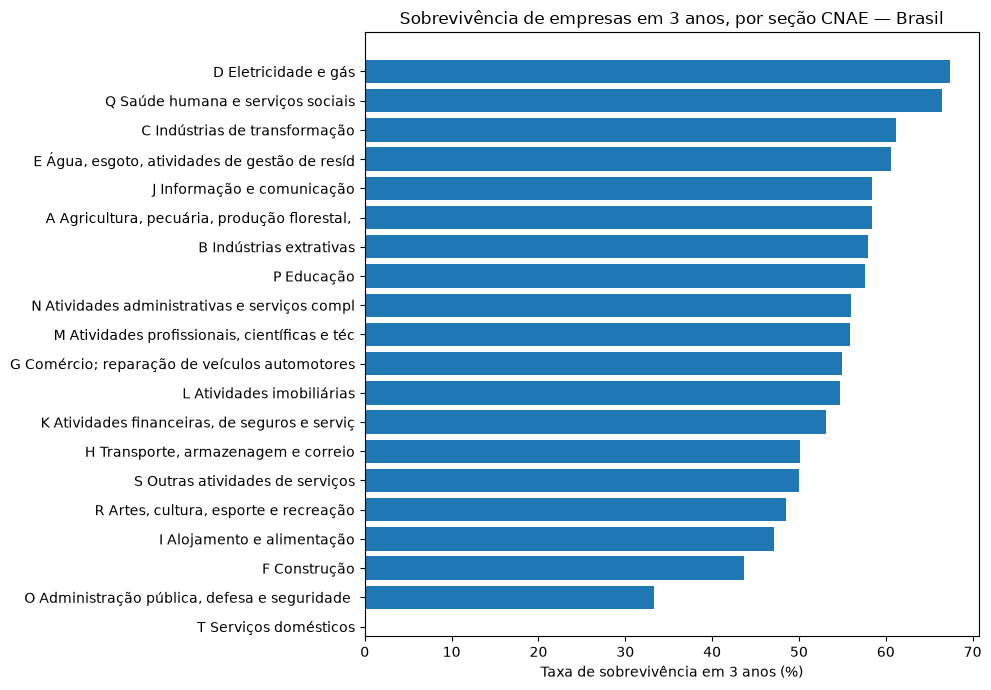

Maior sobrevivência: D Eletricidade e gás
Menor sobrevivência: U Organismos internacionais e outras instituições extraterritoriais


In [10]:
import matplotlib.pyplot as plt

sob3_por_secao = (
    sob3[(sob3["faixa_pessoal"] == "Total") & (sob3["secao_cnae"] != "Total")]
    .sort_values("Valor", ascending=False)   # maior taxa primeiro
)

plt.figure(figsize=(10, 7))
plt.barh(sob3_por_secao["secao_cnae"].str.slice(0, 45), sob3_por_secao["Valor"])
plt.gca().invert_yaxis()
plt.title("Sobrevivência de empresas em 3 anos, por seção CNAE — Brasil")
plt.xlabel("Taxa de sobrevivência em 3 anos (%)")
plt.tight_layout()
plt.show()

print("Maior sobrevivência:", sob3_por_secao.iloc[0]["secao_cnae"])
print("Menor sobrevivência:", sob3_por_secao.iloc[-1]["secao_cnae"])

> **📌 Nota de condução** — Pergunta de amarração com a exposição: 'o que fizemos aqui é pesquisa descritiva ou correlacional?'. Resposta esperada: descrevemos uma associação entre porte (ordinal) e sobrevivência (razão) sem afirmar causa — e há explicações alternativas (capital inicial, setor, experiência do fundador). Reserve ~10 min para essa discussão.

## Seção 4 — Perguntas de interpretação

Responda por escrito, editando esta célula:

**1.** A afirmação *"a maioria das empresas fecha no primeiro ano"* é sustentada pelos dados?
Reescreva-a em versão fiel ao que os dados mostram.

*Sua resposta:*

**2.** Empresas com mais pessoal assalariado apresentam maior sobrevivência. Cite **duas
explicações alternativas** para essa associação, além de "tamanho protege".

*Sua resposta:*

**3.** Que outra pergunta esta base permitiria responder? Classifique-a como **descritiva**
ou **correlacional**.

*Sua resposta:*

**4. (Projeto individual)** Anote uma pergunta que você gostaria de investigar no semestre e
classifique-a como descritiva ou correlacional.

*Sua resposta:*

---
### Antes de sair

1. Salve e compartilhe o link do notebook;
2. **Tarefa:** ler o capítulo de GIL (2019) sobre formulação de problemas e hipóteses e
**trazer por escrito uma pergunta de pesquisa** sobre tema empresarial ou econômico do seu
interesse — ela será trabalhada na oficina do encontro 3.